<a href="https://colab.research.google.com/github/AhmedGDeeb/DataTalksClub/blob/main/machine-learning-zoomcamp/cohorts/2026/homework/04-evaluation/homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# setup

In [84]:
!pip install numpy pandas tqdm matplotlib scikit-learn

In [85]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

# Utils

In [86]:
def confusion_at_thresholds(y_true, y_pred, step=0.01, start=0.0, end=1.0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    thresholds = np.arange(start, end + step / 2, step)  # include `end`
    rows = []

    for t in thresholds:
        y_hat = (y_pred >= t).astype(int)

        tp = int(((y_hat == 1) & (y_true == 1)).sum())
        tn = int(((y_hat == 0) & (y_true == 0)).sum())
        fp = int(((y_hat == 1) & (y_true == 0)).sum())
        fn = int(((y_hat == 0) & (y_true == 1)).sum())

        rows.append({
            "threshold": round(float(t), 2),
            "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        })

    return pd.DataFrame(rows)

In [87]:
def train(df_train, y_train, unfitted_model):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = unfitted_model.fit(X_train, y_train)

    return dv, model

In [88]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

# Get Data

> This homework uses the pinned 2026 lead-scoring release in the course
> repository. The plan and report are available in `cohorts/2026/data/`.

In this homework, we will use the 2026 lead-scoring dataset. Download it from [here](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv).


In [89]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv')

> In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not.


# Data Preparation

* Check if the missing values are presented in the features.
* If there are missing values:
    * For categorical features, replace them with 'NA'
    * For numerical features, replace with with 0.0

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   object 
 1   industry                  4760 non-null   object 
 2   employment_status         4806 non-null   object 
 3   location                  4792 non-null   object 
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [91]:
# Categorical (object) columns -> fill with 'NA'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('NA')

# Numerical (int64, float64) columns -> fill with 0.0
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(0.0)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   object 
 1   industry                  5000 non-null   object 
 2   employment_status         5000 non-null   object 
 3   location                  5000 non-null   object 
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [93]:
df.sample(10)

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
3376,organic_search,manufacturing,employed,north_america,58088.0,5,9,0.84,1
2817,referral,retail,employed,south_america,38487.0,3,8,0.76,1
925,NA,technology,self_employed,asia,93721.0,3,7,0.65,1
3844,paid_ads,technology,unemployed,north_america,68305.0,1,0,0.02,0
4052,NA,technology,employed,africa,57026.0,4,7,0.74,1
4923,social_media,technology,employed,africa,59362.0,1,5,0.56,1
1560,paid_ads,healthcare,self_employed,NA,59499.0,2,6,0.42,0
1148,events,manufacturing,employed,south_america,53460.0,2,3,0.40,1
2358,referral,education,student,north_america,12000.0,0,3,0.28,0
3721,social_media,manufacturing,employed,europe,56176.0,3,6,0.65,1


Split the data into 3 parts with these exact calls:

```python
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [94]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [95]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 2764 to 2242
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1000 non-null   object 
 1   industry                  1000 non-null   object 
 2   employment_status         1000 non-null   object 
 3   location                  1000 non-null   object 
 4   annual_income             1000 non-null   float64
 5   number_of_courses_viewed  1000 non-null   int64  
 6   interaction_count         1000 non-null   int64  
 7   lead_score                1000 non-null   float64
 8   converted                 1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 78.1+ KB


In [96]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 4740 to 357
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               3000 non-null   object 
 1   industry                  3000 non-null   object 
 2   employment_status         3000 non-null   object 
 3   location                  3000 non-null   object 
 4   annual_income             3000 non-null   float64
 5   number_of_courses_viewed  3000 non-null   int64  
 6   interaction_count         3000 non-null   int64  
 7   lead_score                3000 non-null   float64
 8   converted                 3000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 234.4+ KB


In [97]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 913 to 4559
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1000 non-null   object 
 1   industry                  1000 non-null   object 
 2   employment_status         1000 non-null   object 
 3   location                  1000 non-null   object 
 4   annual_income             1000 non-null   float64
 5   number_of_courses_viewed  1000 non-null   int64  
 6   interaction_count         1000 non-null   int64  
 7   lead_score                1000 non-null   float64
 8   converted                 1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 78.1+ KB


In [98]:
X_train = df_train.drop(columns=['converted'])
y_train = df_train['converted']

X_test = df_test.drop(columns=['converted'])
y_test = df_test['converted']

X_val = df_val.drop(columns=['converted'])
y_val = df_val['converted']


# Question 1

### ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `lead_score`
- `number_of_courses_viewed`
- `interaction_count`
- `annual_income`

In [99]:
max_auc_feature, max_AUC = None, -1
cols = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']
for col in cols:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    print(f"{col:30s} AUC = {auc:.3f}")
    if auc > max_AUC:
        max_auc_feature, max_AUC = col, auc

lead_score                     AUC = 0.788
number_of_courses_viewed       AUC = 0.723
interaction_count              AUC = 0.765
annual_income                  AUC = 0.608


# Answer

In [100]:
max_auc_feature

'lead_score'

# Question 2

### Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.532
- 0.632
- 0.732
- 0.832

In [101]:
# ---- DictVectorizer for one-hot encoding ----
dv = DictVectorizer(sparse=False)

train_dicts = X_train.to_dict(orient='records')
val_dicts   = X_val.to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val   = dv.transform(val_dicts)

# ---- Train logistic regression ----
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# ---- Predict and evaluate ----
y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

# Answer

In [102]:
round(auc, 3)

np.float64(0.732)

# Question 3

### Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect? Ignore thresholds at which both metrics are zero, and choose the threshold with the smallest absolute difference between precision and recall.

- 0.43
- 0.63
- 0.73
- 0.83

In [103]:
df_scores = confusion_at_thresholds(y_val, y_pred, step=0.01)
df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores.loc[df_scores['precision'] < 0, 'precision'] = 0
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores.loc[df_scores['recall'] < 0, 'recall'] = 0

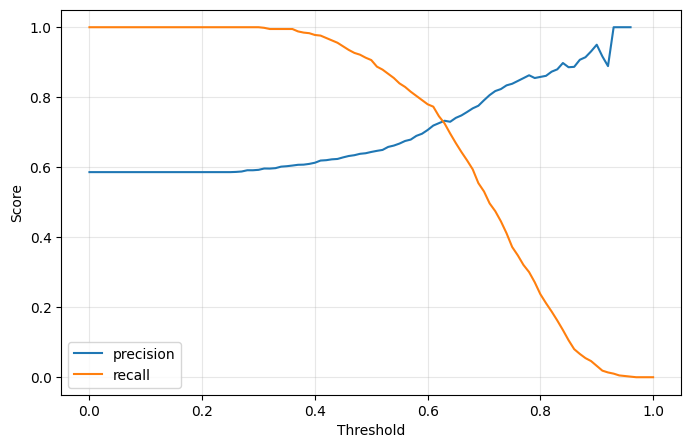

In [104]:
plt.figure(figsize=(8, 5))
plt.plot(df_scores["threshold"], df_scores["precision"], label="precision")
plt.plot(df_scores["threshold"], df_scores["recall"],    label="recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [105]:
mask = (df_scores["precision"] > 0) & (df_scores["recall"] > 0)
subset = df_scores[mask].copy()
subset["diff"] = (subset["precision"] - subset["recall"]).abs()

best = subset.loc[subset["diff"].idxmin()]

best

,63
threshold,0.630000
tp,425.000000
tn,259.000000
fp,155.000000
fn,161.000000
precision,0.732759
recall,0.725256
diff,0.007503


# Answer

In [106]:
round(best['threshold'], 2)

np.float64(0.63)

# Question 4

### F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.21
- 0.41
- 0.61
- 0.81

In [107]:
df_scores['f1'] = 2 * (df_scores['precision'] * df_scores['recall']) / (df_scores['precision'] + df_scores['recall'])
df_scores.loc[df_scores['f1'] < 0, 'f1'] = 0

best_f1 = df_scores.loc[df_scores["f1"].idxmax()]

best_f1

,41
threshold,0.410000
tp,572.000000
tn,62.000000
fp,352.000000
fn,14.000000
precision,0.619048
recall,0.976109
f1,0.757616


# Answer

In [108]:
round(best_f1['threshold'], 3)

np.float64(0.41)

# Question 5

### 5-Fold CV

Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.001
- 0.007
- 0.013
- 0.060

In [109]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    X_train = df_train.drop(columns=['converted'])
    y_train = df_train['converted']
    X_val = df_val.drop(columns=['converted'])
    y_val = df_val['converted']

    unfitted_model = LogisticRegression(C=1.0, max_iter=10000)
    dv, model = train(X_train, y_train, unfitted_model)
    y_pred = predict(X_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

# Answer

In [110]:
round(np.std(scores), 3)

np.float64(0.013)

# Question 6





### Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean ROC AUC as well as the std (round the mean and std to 3 decimal digits).

Which `C` leads to the best mean ROC AUC?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [111]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

results = {}

for C in tqdm([0.000001, 0.001, 1]):

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        X_train = df_train.drop(columns=['converted'])
        y_train = df_train['converted']
        X_val = df_val.drop(columns=['converted'])
        y_val = df_val['converted']

        unfitted_model = LogisticRegression(C=C, max_iter=10000)
        dv, model = train(X_train, y_train, unfitted_model)
        y_pred = predict(X_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    mean_auc = float(np.mean(scores))
    std_auc  = float(np.std(scores))
    results[C] = (mean_auc, std_auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))


  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.615 +- 0.019
C=0.001 0.783 +- 0.013
C=1 0.792 +- 0.013


In [112]:
rounded = {C: (round(m, 3), round(s, 3)) for C, (m, s) in results.items()}

best_C = sorted(
    rounded.items(),
    key=lambda kv: (-kv[1][0], kv[1][1], kv[0]) # -mean, std, C
)[0][0]

# Answer

In [113]:
best_C

1

# Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw04
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.